# **Bag of Words Implementation Using Python (From Scratch)**

**Step 1: Preprocessing the Text Data**


 Defining a simple function to process text, including tokenization, lowercasing, and removing punctuation.

In [ ]:
from collections import defaultdict
import string

# Sample text data: sentences
corpus = [
    "Python is amazing and fun.",
    "Python is not just fun but also powerful.",
    "Learning Python is fun!",
]
# Function to preprocess text
def preprocess(text):
    # Convert to lowercase
    text = text.lower()
    # Remove punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))
    # Tokenize: split the text into words
    tokens = text.split()
    return tokens

# Apply preprocessing to the sample corpus
processed_corpus = [preprocess(sentence) for sentence in corpus]
print(processed_corpus)

[['python', 'is', 'amazing', 'and', 'fun'], ['python', 'is', 'not', 'just', 'fun', 'but', 'also', 'powerful'], ['learning', 'python', 'is', 'fun']]


**Step 2: Build Vocabulary**


Now, we need to scan through all the documents and build a complete list of unique words, that is our vocabulary.

In [ ]:
# Initialize an empty set for the vocabulary
vocabulary = set()

# Build the vocabulary
for sentence in processed_corpus:
    vocabulary.update(sentence)

# Convert to a sorted list
vocabulary = sorted(list(vocabulary))
print("Vocabulary:", vocabulary)

Vocabulary: ['also', 'amazing', 'and', 'but', 'fun', 'is', 'just', 'learning', 'not', 'powerful', 'python']


**Step 3: Calculate Word Frequencies and Vectorize**


We'll now calculate the frequency of each word in the vocabulary for every document in the processed corpus.

In [ ]:
def create_bow_vector(sentence, vocab):
    vector = [0] * len(vocab)  # Initialize a vector of zeros
    for word in sentence:
        if word in vocab:
            idx = vocab.index(word)  # Find the index of the word in the vocabulary
            vector[idx] += 1  # Increment the count at that index
    return vector

In [ ]:
#At this point, you will have created a Bag of Words representation for each document in your corpus.


# Create BoW vector for each sentence in the processed corpus
bow_vectors = [create_bow_vector(sentence, vocabulary) for sentence in processed_corpus]
print("Bag of Words Vectors:")
for vector in bow_vectors:
    print(vector)


Bag of Words Vectors:
[0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1]
[1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1]
[0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1]


# **Using Scikit-learn’s CountVectorizer**

The Python function that we use for tokenization is CountVectorizer, which is imported from the sklearn.feature_extraction.text. One of the features of CountVectorizer is max_features, which represents the maximum number of words you’d like to have in the bag of words model. In this case, we use None, meaning that all features will be used.

After creating an instance of CountVectorizer, use the .fit_transform() method to create the bag of words model. Next, use the .toarray() to convert the bag of words model to numpy arrays that can be fed to a machine learning model.

Once fitted, CountVectorizer has built a dictionary of feature indices. The index value of a word in the vocabulary is linked to its frequency in the whole training corpus.

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
# Original corpus
corpus = [
    "Python is amazing and fun.",
    "Python is not just fun but also powerful.",
    "Learning Python is fun!",
]
# Create a CountVectorizer Object
vectorizer = CountVectorizer()
# Fit and transform the corpus
X = vectorizer.fit_transform(corpus)
# Print the generated vocabulary
print("Vocabulary:", vectorizer.get_feature_names_out())
# Print the Bag-of-Words matrix
print("BoW Representation:")
print(X.toarray())

Vocabulary: ['also' 'amazing' 'and' 'but' 'fun' 'is' 'just' 'learning' 'not'
 'powerful' 'python']
BoW Representation:
[[0 1 1 0 1 1 0 0 0 0 1]
 [1 0 0 1 1 1 1 0 1 1 1]
 [0 0 0 0 1 1 0 1 0 0 1]]


**Example: Applying Bag of Words**

Here are the steps that we will take:

CountVectorizer tokenizes the text, removes punctuation, and lowercase the words automatically.

.fit_transform(corpus) converts the corpus into a document-term matrix, where each row represents a document and each column represents a word from the vocabulary.

X_dense is the dense matrix that represents the frequency of each word in each document.

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
# Sample corpus of movie reviews
corpus = [
    "I loved the movie, it was fantastic!",
    "The movie was okay, but not great.",
    "I hated the movie, it was terrible.",
]

# Initialize the CountVectorizer
vectorizer = CountVectorizer()

# Fit and transform the corpus to a document-term matrix
X = vectorizer.fit_transform(corpus)

# Convert the document-term matrix into a dense format (optional for visualization)
X_dense = X.toarray()

# Get the vocabulary (mapping of words to index positions)
vocab = vectorizer.get_feature_names_out()

# Print the vocabulary and document-term matrix
print("Vocabulary:", vocab)
print("Document-Term Matrix:\n", X_dense)

Vocabulary: ['but' 'fantastic' 'great' 'hated' 'it' 'loved' 'movie' 'not' 'okay'
 'terrible' 'the' 'was']
Document-Term Matrix:
 [[0 1 0 0 1 1 1 0 0 0 1 1]
 [1 0 1 0 0 0 1 1 1 0 1 1]
 [0 0 0 1 1 0 1 0 0 1 1 1]]


# **TF-IDF: An Extension to Bag of Words**


Term Frequency (TF) represents the frequency of a term in a document. Inverse Document Frequency (IDF) reduces the impact of commonly occurring words across multiple documents. The TF-IDF score is calculated by multiplying the two metrics.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
# Sample corpus
corpus = [
    "Python is amazing and fun.",
    "Python is not just fun but also powerful.",
    "Learning Python is fun!",
]

# Create the Tf-idf vectorizer
tfidf_vectorizer = TfidfVectorizer()

# Fit and transform the corpus
X_tfidf = tfidf_vectorizer.fit_transform(corpus)

# Show the Vocabulary
print("Vocabulary:", tfidf_vectorizer.get_feature_names_out())

# Show the TF-IDF Matrix
print("TF-IDF Representation:")
print(X_tfidf.toarray())

Vocabulary: ['also' 'amazing' 'and' 'but' 'fun' 'is' 'just' 'learning' 'not'
 'powerful' 'python']
TF-IDF Representation:
[[0.         0.57292883 0.57292883 0.         0.338381   0.338381
  0.         0.         0.         0.         0.338381  ]
 [0.40667606 0.         0.         0.40667606 0.24018943 0.24018943
  0.40667606 0.         0.40667606 0.40667606 0.24018943]
 [0.         0.         0.         0.         0.41285857 0.41285857
  0.         0.69903033 0.         0.         0.41285857]]


In [ ]:
!pip install nltk
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
!pip install gensim
from gensim.models import Word2Vec
from nltk.tokenize import word_tokenize

# Sample corpus
corpus = [
    "The quick brown fox jumps over the lazy dog",
    "I love natural language processing",
    "Word embeddings are fun to work with"
]

# Tokenize the corpus
tokenized_corpus = [word_tokenize(sentence.lower()) for sentence in corpus]

# Train the Word2Vec model
model = Word2Vec(sentences=tokenized_corpus, vector_size=100, window=5, min_count=1, sg=0)

# Get the vector representation of a word
word_vector = model.wv['natural']
print(word_vector)

[ 9.7702928e-03  8.1651136e-03  1.2809718e-03  5.0975787e-03
  1.4081288e-03 -6.4551616e-03 -1.4280510e-03  6.4491653e-03
 -4.6173059e-03 -3.9930656e-03  4.9244044e-03  2.7130984e-03
 -1.8479753e-03 -2.8769434e-03  6.0107317e-03 -5.7167388e-03
 -3.2367026e-03 -6.4878250e-03 -4.2346325e-03 -8.5809948e-03
 -4.4697891e-03 -8.5112294e-03  1.4037776e-03 -8.6181965e-03
 -9.9166557e-03 -8.2016252e-03 -6.7726658e-03  6.6805850e-03
  3.7845564e-03  3.5616636e-04 -2.9579818e-03 -7.4283206e-03
  5.3341867e-04  4.9989222e-04  1.9561886e-04  8.5259555e-04
  7.8633073e-04 -6.8160298e-05 -8.0070542e-03 -5.8702733e-03
 -8.3829118e-03 -1.3120425e-03  1.8206370e-03  7.4171280e-03
 -1.9634271e-03 -2.3252917e-03  9.4871549e-03  7.9704521e-05
 -2.4045217e-03  8.6048469e-03  2.6870037e-03 -5.3439722e-03
  6.5881060e-03  4.5101536e-03 -7.0544672e-03 -3.2317400e-04
  8.3448651e-04  5.7473574e-03 -1.7176545e-03 -2.8065301e-03
  1.7484308e-03  8.4717153e-04  1.1928272e-03 -2.6342822e-03
 -5.9857843e-03  7.32298

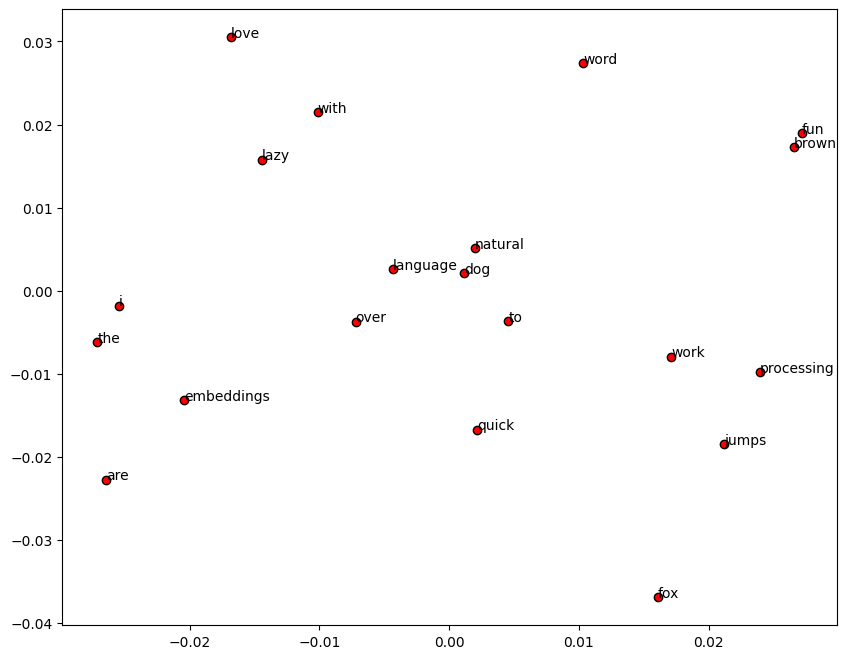

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Retrieve the word vectors and corresponding labels
words = list(model.wv.index_to_key)
word_vectors = [model.wv[word] for word in words]

# Reduce dimensions to 2D using PCA
pca = PCA(n_components=2)
word_vectors_2d = pca.fit_transform(word_vectors)

# Plot the words
plt.figure(figsize=(10, 8))
plt.scatter(word_vectors_2d[:, 0], word_vectors_2d[:, 1], edgecolors='k', c='r')
for i, word in enumerate(words):
    plt.annotate(word, (word_vectors_2d[i, 0], word_vectors_2d[i, 1]))
plt.show()